# 01. LangChain V1 개요

> LangChain V1은 체인(LCEL) 중심에서 **에이전트 우선**으로 무게 중심을 옮긴 메이저 업데이트예요. 패키지 재구조화, `init_chat_model`, Content Blocks, V0 → V1 마이그레이션 포인트를 한 번에 정리해요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. LangChain V0에서 V1으로의 철학적 전환(체인 기반 → 에이전트 우선)을 설명할 수 있어요
2. V1 패키지 재구조화 내용을 파악하고 올바른 import 경로를 사용할 수 있어요
3. `init_chat_model("provider:model")` 통합 패턴으로 다양한 모델을 초기화할 수 있어요
4. Content Blocks 개념을 이해하고 멀티모달 메시지를 구성할 수 있어요
5. V0에서 V1으로 마이그레이션 시 주요 Breaking Change를 식별할 수 있어요

## 사전 지식

- LangChain V0 기본 사용 경험 (체인, 모델, 프롬프트)
- Python 3.10+ 환경 준비
- OpenAI API 키 보유

## LangChain V1이란?

LangChain V1은 2025년 출시된 메이저 버전으로, LLM 생태계의 변화를 반영한 **근본적인 철학 전환**을 담고 있어요.

### V0 → V1 타임라인

| 버전 | 출시 | 핵심 특징 |
|------|------|----------|
| v0.0.1 | 2022년 | LLM 체인, 에이전트 초기 형태 |
| v0.1.0 | 2024년 | 안정화, `langchain-core` 분리 |
| v1.0.0 | 2025년 | 에이전트 우선, 패키지 재구조화 |

### 철학의 전환: 체인 기반 → 에이전트 우선

V0는 **LCEL(LangChain Expression Language)** 체인을 중심으로 설계되었어요. `pipe(|)` 연산자로 컴포넌트를 연결하는 방식이죠.

V1은 **에이전트가 1등 시민(first-class citizen)** 으로 바뀌었어요. 모델이 도구를 선택하고, 추론하며, 반복적으로 실행하는 에이전트 패턴을 기본으로 합니다.

비유하자면, V0는 **조립 설명서**와 비슷해요. 순서대로 부품을 연결하면 완성품이 나와요. V1은 **숙련된 요리사**에 가까워요. 냉장고에 있는 재료(도구)를 보고, 상황에 맞게 레시피(추론)를 결정하고, 직접 요리(실행)해요.

> 🎯 **강의 포인트**: V0에서 `from langchain_core.messages import HumanMessage`처럼 `langchain_core`를 직접 import하던 학생이 많았어요. V1에서는 `from langchain.messages import HumanMessage`처럼 최상위 `langchain` 패키지에서 import합니다. 이 변화가 왜 생겼는지 함께 살펴봐요.

> 🔑 **핵심 개념**: LangChain V1의 핵심 변화는 "LLM을 체인으로 묶는다"에서 "LLM이 스스로 판단하는 에이전트를 만든다"로의 전환이에요.

## 전체 아키텍처

LangChain V1 생태계는 세 가지 레이어로 구성되어 있어요:

```mermaid
flowchart TD
    A["개발자 코드<br>(Your Code)"] --> B
    
    subgraph B["LangChain V1 패키지"]
        B1["langchain<br>(메인 SDK)"]
        B2["langchain-community<br>(서드파티 통합)"]
        B3["langchain-openai<br>(OpenAI 통합)"]
        B4["langchain-anthropic<br>(Anthropic 통합)"]
        B5["langchain-classic<br>(V0 호환 레이어)"]
    end
    
    subgraph C["런타임 & 하네스"]
        C1["LangGraph<br>(그래프 런타임)"]
        C2["Deep Agents<br>(에이전트 하네스)"]
    end
    
    B --> C
    C --> D["LLM 공급자<br>(OpenAI, Anthropic, Google...)"] 

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    
    class A input
    class B1,B2,B3,B4,B5 process
    class C1,C2 output
    class D storage
```

### V1 패키지 구조

V1에서는 `langchain` 패키지가 5개의 핵심 모듈로 정리되었어요:

| 모듈 | 용도 | 주요 import |
|------|------|-------------|
| `langchain.agents` | 에이전트 생성, 실행 | `create_agent` |
| `langchain.messages` | 메시지 타입 | `HumanMessage`, `AIMessage`, `SystemMessage`, `ToolMessage` |
| `langchain.chat_models` | 모델 초기화 | `init_chat_model` |
| `langchain.tools` | 도구 정의 | `tool` 데코레이터 |
| `langchain.retrievers` | 검색/RAG | `BaseRetriever` |

V0에서 `langchain_core`, `langchain_openai` 등에 분산되어 있던 import가 `langchain`으로 통합되었어요. 기존 코드 호환을 위한 `langchain-classic` 패키지도 제공해요.

## 1. 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 변수 로드
# ---------------------------------------------------
# .env 파일에서 OPENAI_API_KEY 등을 읽어와요
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# ---------------------------------------------------
# LangSmith 추적 설정 (선택사항)
# ---------------------------------------------------
# LangSmith로 실행 이력을 추적하고 싶을 때 설정해요
# .env에 LANGCHAIN_API_KEY가 있으면 자동으로 활성화됩니다
import os

# 추적을 활성화하려면 아래 주석을 해제하세요
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-V1-Overview"

# 환경 설정 완료

환경 설정 완료


## 2. V1 모델 초기화: `init_chat_model`

V1의 가장 큰 변화 중 하나는 `init_chat_model("provider:model")` 통합 패턴이에요.

V0에서는 각 공급자마다 다른 클래스를 사용해야 했어요:
```python
# V0 방식 (더 이상 권장하지 않아요)
from langchain_openai import ChatOpenAI
from langchain_anthropic import ChatAnthropic

openai_model = ChatOpenAI(model="gpt-4o-mini")
anthropic_model = ChatAnthropic(model="claude-sonnet-4-5")
```

V1에서는 하나의 함수로 모든 공급자를 통일해요:

> 🔑 **핵심 개념**: `init_chat_model("provider:model")` 패턴은 모델 공급자를 코드에서 분리(decouple)해요. 덕분에 OpenAI → Anthropic 교체가 문자열 하나만 바꾸면 됩니다.

> 💡 **실무 팁**: `provider:model` 형식 외에도 `model` 만 지정하면 `OPENAI_API_KEY` 환경변수로 자동 감지해요. 프로덕션에서는 명시적으로 provider를 지정하는 것이 안전합니다.

In [3]:
# ---------------------------------------------------
# V1 모델 초기화
# ---------------------------------------------------
# init_chat_model: 모든 공급자를 통일된 인터페이스로 초기화해요
from langchain.chat_models import init_chat_model

# 기본 모델: gpt-4o-mini (비용 효율, 학생 접근성 우선)
# 다른 모델로 교체하려면 문자열만 바꾸면 돼요:
#   Anthropic:  "anthropic:claude-sonnet-4-5"
#   Google:     "google_genai:gemini-2.0-flash"
model = init_chat_model("openai:gpt-4o-mini")

print(f"모델 타입: {type(model).__name__}")
print(f"모델 이름: {model.model_name}")

모델 타입: ChatOpenAI
모델 이름: gpt-4o-mini


In [4]:
# ---------------------------------------------------
# 기본 메시지 호출 테스트
# ---------------------------------------------------
# V1에서 메시지 타입은 langchain.messages에서 import해요
from langchain.messages import HumanMessage, SystemMessage

# 간단한 질문을 보내봐요
messages = [
    SystemMessage(content="당신은 친절한 AI 어시스턴트예요."),
    HumanMessage(content="LangChain V1의 가장 큰 특징을 한 문장으로 말해주세요."),
]

response = model.invoke(messages)

# V1에서 AIMessage.content는 문자열 또는 Content Blocks 리스트
print(f"응답 타입: {type(response).__name__}")
print(f"응답 내용: {response.content}")

응답 타입: AIMessage
응답 내용: LangChain V1의 가장 큰 특징은 자연어 처리 모델과 다양한 데이터 소스, 도구, 프레임워크를 통합하여 복잡한 작업을 수행할 수 있도록 하는 강력한 프레임워크라는 것입니다.


## 3. Content Blocks: 멀티모달 표준화

### 왜 Content Blocks가 필요할까요?

V0에서는 OpenAI의 응답은 단순 문자열, Anthropic의 응답은 블록 리스트로 **공급자마다 응답 형식이 달랐어요**. 공급자를 바꿀 때마다 응답 파싱 코드도 바꿔야 했죠. Content Blocks는 이 문제를 해결하기 위해 **모든 공급자의 응답을 하나의 표준 형식**으로 통일해요.

V1의 핵심 신기능 중 하나는 **Content Blocks(컨텐츠 블록)** 이에요.

V0에서는 텍스트 응답이 단순 문자열로 반환되었어요:
```python
# V0: AIMessage.content = "텍스트 응답"
print(response.content)  # 문자열
```

V1에서는 텍스트, 이미지, 도구 호출 등이 모두 **Content Block 리스트**로 통일되어 있어요:

```mermaid
flowchart LR
    A["AIMessage"] --> B["content<br>(리스트)"] 
    B --> C1["TextBlock<br>{'type': 'text', 'text': '...'}"] 
    B --> C2["ToolUseBlock<br>{'type': 'tool_use', 'name': '...'}"] 
    B --> C3["ImageBlock<br>{'type': 'image', 'source': '...'}"] 
    
    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    
    class A input
    class B process
    class C1,C2,C3 output
```

> 🔑 **핵심 개념**: Content Blocks는 공급자 종속적인 응답 형식을 **표준화**해요. OpenAI, Anthropic, Google 등 어떤 모델을 쓰더라도 동일한 방식으로 응답을 파싱할 수 있어요.

> ⚠️ **자주 하는 실수**: V0 코드에서 `response.content`를 그냥 문자열로 처리하던 코드가 V1에서는 리스트를 받아 오류가 나는 경우가 있어요. `response.text()` 대신 `response.content`를 확인하거나 `response.text` 속성을 사용하세요.

In [5]:
# ---------------------------------------------------
# Content Blocks 구조 확인
# ---------------------------------------------------
# 단순 텍스트 응답에서 Content Block 구조를 살펴봐요
from langchain.messages import HumanMessage

response = model.invoke([HumanMessage(content="안녕하세요!")])

# === AIMessage 구조 ===
print(f"content 타입: {type(response.content)}")  # str 또는 list
print(f"content 값: {response.content}")
print()

# V1에서 텍스트 추출하는 방법
# content가 문자열이면 그대로 사용
# content가 리스트(Content Blocks)면 text 타입 블록을 찾아요
if isinstance(response.content, str):
    text = response.content
elif isinstance(response.content, list):
    # Content Blocks 리스트에서 텍스트 추출
    text = " ".join(
        block["text"]
        for block in response.content
        if isinstance(block, dict) and block.get("type") == "text"
    )
else:
    text = str(response.content)

print(f"추출된 텍스트: {text}")

=== AIMessage 구조 ===
content 타입: <class 'str'>
content 값: 안녕하세요! 어떻게 도와드릴까요?

추출된 텍스트: 안녕하세요! 어떻게 도와드릴까요?


In [6]:
# ---------------------------------------------------
# HumanMessage에 Content Blocks 사용하기
# ---------------------------------------------------
# 멀티모달 메시지를 Content Blocks 형식으로 구성해요
# (이미지 URL이 유효한 경우 실제 이미지 분석이 가능해요)
from langchain.messages import HumanMessage

# 텍스트만 있는 Content Block 형식
text_block_message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": "Python의 장점을 한 줄로 설명해주세요."
        }
    ]
)

response = model.invoke([text_block_message])
# Content Block 형식 응답:
print(response.content)

Content Block 형식 응답:
Python은 읽기 쉽고 배우기 쉬우며, 다양한 라이브러리를 통해 빠른 개발이 가능한 언어입니다.


## 4. `create_agent`: 에이전트 생성 표준화

V0에서는 `create_react_agent`(LangGraph)를 사용했어요. V1에서는 `langchain.agents`의 `create_agent`가 표준이에요.

### V0 vs V1 에이전트 생성 비교

| 항목 | V0 | V1 |
|------|----|----|  
| import | `from langgraph.prebuilt import create_react_agent` | `from langchain.agents import create_agent` |
| 패턴 | ReAct 고정 | 다양한 패턴 지원 |
| 시스템 프롬프트 | `state_modifier` 파라미터 | `system_prompt` 파라미터 |
| 모델 초기화 | `ChatOpenAI()` 직접 | `init_chat_model()` 권장 |

> 🎯 **강의 포인트**: `create_agent`는 `create_react_agent`를 내부적으로 LangGraph 기반으로 구현하지만, 더 단순한 인터페이스를 제공해요. Part 5에서 깊이 다루지만, 여기서 기본 패턴을 미리 맛볼 수 있어요.

> 💡 **실무 팁**: `create_agent`는 내부적으로 LangGraph `StateGraph`를 사용해요. 더 세밀한 제어가 필요하면 직접 StateGraph를 구성하세요 (Part 2에서 배워요).

In [7]:
# ---------------------------------------------------
# create_agent 기본 예제
# ---------------------------------------------------
# V1의 표준 에이전트 생성 패턴을 확인해요
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain.tools import tool


# 간단한 도구 정의 (V1 @tool 데코레이터)
@tool
def get_weather(city: str) -> str:
    """특정 도시의 날씨를 조회해요.

    Args:
        city: 날씨를 알고 싶은 도시명
    """
    # 실제 구현에서는 날씨 API를 호출하지만, 여기서는 시뮬레이션해요
    return f"{city}의 현재 날씨는 맑음, 기온 22도입니다."


@tool
def calculate(expression: str) -> str:
    """수학 표현식을 계산해요.

    Args:
        expression: 계산할 수식 (예: '2 + 3 * 4')
    """
    # 간단한 수식 평가 (실무에서는 보안 검토 필요)
    try:
        result = eval(expression)  # noqa: S307
        return f"계산 결과: {result}"
    except Exception as e:
        return f"계산 오류: {e}"


# 모델과 도구로 에이전트 생성
agent_model = init_chat_model("openai:gpt-4o-mini")
tools = [get_weather, calculate]

agent = create_agent(
    model=agent_model,
    tools=tools,
    system_prompt="당신은 날씨 정보와 수학 계산을 도와주는 어시스턴트예요.",
)

print(f"에이전트 생성 완료: {type(agent).__name__}")
print("등록된 도구:", [t.name for t in tools])

에이전트 생성 완료: CompiledStateGraph
등록된 도구: ['get_weather', 'calculate']


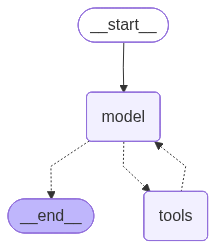

In [8]:
# 그래프 흐름: START → agent → tools → agent → ... → END
# agent 노드: LLM이 사용자 메시지를 받아 응답하거나 도구 호출을 결정해요
# tools 노드: tool_call이 있으면 도구를 실행해요
# 조건부 엣지: tool_call 유무에 따라 tools 또는 END로 분기해요
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

In [9]:
# ---------------------------------------------------
# 에이전트 실행
# ---------------------------------------------------
# create_agent가 반환한 그래프를 실행해봐요
from langchain.messages import HumanMessage

# 도구 사용이 필요한 질문
response = agent.invoke(
    {"messages": [HumanMessage(content="서울 날씨가 어때요? 그리고 15 곱하기 23은?")]}
)

# 마지막 메시지 출력
last_message = response["messages"][-1]
# 에이전트 응답:
print(last_message.content)

에이전트 응답:
서울의 현재 날씨는 맑고, 기온은 22도입니다. 그리고 15 곱하기 23은 345입니다.


## 5. V0 → V1 마이그레이션 가이드

V0 코드를 V1으로 마이그레이션할 때 주의해야 할 **Breaking Changes**를 정리했어요.

### 주요 변경 사항

| 항목 | V0 | V1 | 영향 |
|------|----|----|------|
| 메시지 import | `from langchain_core.messages import ...` | `from langchain.messages import ...` | 낮음 |
| 모델 초기화 | `ChatOpenAI(model="...")` | `init_chat_model("openai:...")` | 중간 |
| 에이전트 생성 | `create_react_agent` (LangGraph) | `create_agent` (langchain) | 중간 |
| AIMessage 반환 타입 | `content: str` | `content: str \| list` | **높음** |
| 스트리밍 노드 이름 | `"agent"` | `"call_model"` (변경 가능) | 낮음 |
| `.text()` 메서드 | `response.text()` | `response.text` (속성) | **높음** |
| Python 최소 버전 | 3.8+ | **3.10+** | **높음** |

> ⚠️ **자주 하는 실수**: `response.text()`를 `response.text`로 바꾸는 것을 잊어버리는 경우가 많아요. V1에서 `.text()`는 더 이상 메서드가 아니라 속성(property)이에요.

> 💡 **실무 팁**: 기존 V0 코드의 호환성을 유지하고 싶다면 `pip install langchain-classic`을 사용하세요. 하지만 새 프로젝트는 처음부터 V1 API를 사용하는 것을 권장해요.

In [10]:
# ---------------------------------------------------
# Breaking Change 확인: AIMessage 반환 타입
# ---------------------------------------------------
# V1에서 AIMessage.content는 공급자에 따라 str 또는 list일 수 있어요
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage

model = init_chat_model("openai:gpt-4o-mini")

response = model.invoke([HumanMessage(content="1 + 1은?")])

# === V1 AIMessage 반환 타입 확인 ===
print(f"content 타입: {type(response.content).__name__}")
print(f"content: {response.content}")

# V1에서 안전하게 텍스트를 추출하는 방법
# response.text 속성 (V1에서 추가됨) - 항상 문자열 반환
# 주의: OpenAI 모델은 content가 문자열, Anthropic은 Content Blocks 리스트일 수 있어요
print()
# === 안전한 텍스트 추출 ===
if hasattr(response, 'text'):
    # V1 방식: .text 속성 사용
    print(f"response.text: {response.text}")
else:
    # 폴백: content를 직접 처리
    text = response.content if isinstance(response.content, str) else str(response.content)
    print(f"폴백 텍스트: {text}")

=== V1 AIMessage 반환 타입 확인 ===
content 타입: str
content: 1 + 1은 2입니다.

=== 안전한 텍스트 추출 ===
response.text: 1 + 1은 2입니다.


In [11]:
# ---------------------------------------------------
# 스트리밍 응답
# ---------------------------------------------------
# V1에서 스트리밍은 V0와 동일한 방식으로 작동해요
# stream_response() 헬퍼 없이 직접 구현해요
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage

model = init_chat_model("openai:gpt-4o-mini")

# 스트리밍 응답:
# ----------------------------------------

# 모델 응답을 실시간으로 출력해요
for chunk in model.stream([HumanMessage(content="LangChain V1의 장점 3가지를 번호 목록으로 알려주세요.")]):
    print(chunk.content, end="", flush=True)

print()  # 마지막 줄바꿈

스트리밍 응답:
----------------------------------------
LangChain V1의 장점은 다음과 같습니다.

1. **모듈화 및 확장성**: LangChain V1은 다양한 구성 요소로 모듈화되어 있어, 개발자가 필요에 따라 특정 기능을 쉽게 추가하거나 수정할 수 있습니다. 이로 인해 프로젝트의 요구 사항에 맞춰 쉽게 확장할 수 있습니다.

2. **다양한 프레임워크와 호환성**: LangChain V1은 여러 가지 언어 모델과 프레임워크와 호환되며, 이를 통해 개발자는 여러 가지 AI 모델을 손쉽게 통합하여 사용할 수 있습니다. 이로 인해 다양한 적용 분야에서 활용할 수 있는 유연성을 제공합니다.

3. **사용자 친화적인 인터페이스**: LangChain V1은 직관적인 API와 도구를 제공하여 개발자가 쉽게 이해하고 활용할 수 있도록 설계되었습니다. 이를 통해 비전문가라도 AI 모델을 활용하는 데 필요한 진입 장벽을 낮출 수 있습니다.


## 6. V1 Python 버전 요구사항과 현대적 타입 힌트

LangChain V1은 **Python 3.10+** 을 요구해요. 이는 단순한 요구사항 변경이 아니라, V1이 현대 Python 기능을 적극적으로 활용하기 때문이에요.

### Python 3.10+ 주요 기능 활용

| 기능 | 예시 | LangChain V1에서의 활용 |
|------|------|------------------------|
| `match-case` | `match msg_type: case "human":` | 메시지 타입 처리 |
| Union 타입 힌트 | `str \| list` | Content Blocks 타입 |
| `TypeAlias` | `MessageLike = str \| BaseMessage` | SDK 타입 정의 |
| Structural Pattern Matching | 복잡한 메시지 파싱 | 내부 구현 |

> 🎯 **강의 포인트**: `str | list` 같은 V1 타입 힌트는 Python 3.10의 Union 타입 표기법을 사용해요. Python 3.9 이하에서는 `Union[str, list]`를 써야 했죠. 이 변화가 왜 중요한지 설명해봐요.

> 💡 **실무 팁**: 현재 Python 버전을 확인하고, 3.10 미만이라면 업그레이드를 고려하세요. pyenv나 conda로 여러 버전을 관리할 수 있어요.

In [12]:
# ---------------------------------------------------
# Python 버전 및 LangChain 버전 확인
# ---------------------------------------------------
import sys
import langchain
from importlib.metadata import version as pkg_version

# === 환경 정보 ===
print(f"Python 버전: {sys.version}")
print(f"LangChain 버전: {langchain.__version__}")
print(f"LangGraph 버전: {pkg_version('langgraph')}")

# Python 3.10+ 확인
major, minor = sys.version_info.major, sys.version_info.minor
if major >= 3 and minor >= 10:
    # Python 3.10+ 확인: 정상
    pass
else:
    print(f"\n경고: Python {major}.{minor}은 LangChain V1 요구사항(3.10+)을 충족하지 않아요!")

=== 환경 정보 ===
Python 버전: 3.14.4 (main, Apr  7 2026, 20:47:13) [Clang 22.1.1 ]
LangChain 버전: 1.2.15
LangGraph 버전: 1.1.6

Python 3.10+ 확인: 정상


In [13]:
# ---------------------------------------------------
# Python 3.10+ 타입 힌트 사용 예시
# ---------------------------------------------------
# V1 스타일의 현대적인 타입 힌트를 살펴봐요
from langchain.messages import AIMessage, HumanMessage
from langchain_core.messages import BaseMessage  # BaseMessage는 langchain_core에서 가져와요


def extract_text(response: AIMessage) -> str:
    """AIMessage에서 텍스트를 추출해요.

    V1에서 content는 str | list 타입이에요 (Python 3.10+ 표기법).
    """
    # Python 3.10 match-case로 타입 처리
    match response.content:
        case str():  # 문자열인 경우 (대부분의 OpenAI 응답)
            return response.content
        case list():  # Content Blocks 리스트인 경우 (Anthropic 등)
            texts = [
                block["text"]
                for block in response.content
                if isinstance(block, dict) and block.get("type") == "text"
            ]
            return " ".join(texts)
        case _:  # 그 외 (예외 처리)
            return str(response.content)


def process_messages(messages: list[BaseMessage]) -> list[str]:
    """메시지 목록에서 텍스트 내용만 추출해요.

    Python 3.10+ list[BaseMessage] 타입 힌트 사용.
    """
    return [msg.content if isinstance(msg.content, str) else str(msg.content) for msg in messages]


# 테스트
model = init_chat_model("openai:gpt-4o-mini")
response = model.invoke([HumanMessage(content="안녕!")])

text = extract_text(response)
print(f"추출된 텍스트: {text}")

추출된 텍스트: 안녕하세요! 어떻게 도와드릴까요?


## 7. 실습: V0 코드를 V1으로 마이그레이션하기

지금까지 V1의 핵심 변경점을 살펴봤어요. 이제 **직접 손으로 바꿔보면서** 근육 기억을 만들 차례예요. 실무에서 V0 프로젝트를 V1으로 옮기는 작업은 한 번에 끝나지 않아요. 아래 실습으로 가장 자주 마주치는 3가지 변환 패턴을 연습해봐요.

> ⚠️ **자주 하는 실수**: 마이그레이션 시 import 경로만 바꾸고 `response.content` 처리를 잊는 경우가 많아요. 특히 `str | list` 분기 처리를 빠뜨리면 Anthropic 모델에서 런타임 오류가 발생해요.

아래 V0 스타일 코드를 V1 방식으로 변환해보세요.

In [ ]:
# ============================================================
# 구현 예시: V0 스타일 코드를 V1 방식으로 변환
# ============================================================

# V0 스타일 코드 (참고용 - 수정하지 마세요)
# from langchain_openai import ChatOpenAI
# from langchain_core.messages import HumanMessage
# old_model = ChatOpenAI(model="gpt-4o-mini")
# old_response = old_model.invoke([HumanMessage(content="Python의 특징은?")])
# print(old_response.content)  # str로 가정

# 1. V1 import
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage

# 2. V1 모델 초기화
new_model = init_chat_model("openai:gpt-4o-mini")

# 3. 메시지 생성 및 호출
new_response = new_model.invoke([HumanMessage(content="Python의 특징은?")])

# 4. 안전한 텍스트 추출 (str | list 모두 처리)
content = new_response.content
if isinstance(content, str):
    text = content
elif isinstance(content, list):
    text = " ".join(
        block.get("text", "")
        for block in content
        if isinstance(block, dict) and block.get("type") == "text"
    )
else:
    text = str(content)

print(f"V1 응답: {text}")

In [15]:
# ---------------------------------------------------
# 정답 예시 (직접 해보고 나서 확인하세요!)
# ---------------------------------------------------
# 아래 주석을 해제하면 정답을 확인할 수 있어요

# 1. V1 import
# from langchain.chat_models import init_chat_model
# from langchain.messages import HumanMessage
#
# 2. V1 모델 초기화
# new_model = init_chat_model("openai:gpt-4o-mini")
#
# 3. 메시지 생성 및 호출
# new_response = new_model.invoke([HumanMessage(content="Python의 특징은?")])
#
# 4. 안전한 텍스트 추출
# match new_response.content:
#     case str():
#         text = new_response.content
#     case list():
#         text = " ".join(
#             b["text"] for b in new_response.content
#             if isinstance(b, dict) and b.get("type") == "text"
#         )
#     case _:
#         text = str(new_response.content)
#
# print(f"V1 응답: {text}")

# 정답 코드는 주석을 해제해서 확인하세요.

정답 코드는 주석을 해제해서 확인하세요.


## 8. V1 빠른 요약 데모

지금까지 배운 V1 핵심 패턴을 종합해서 실용적인 예제를 만들어봐요.

In [16]:
# ---------------------------------------------------
# V1 핵심 패턴 종합 예제
# ---------------------------------------------------
# init_chat_model + 도구 + create_agent를 모두 사용해요
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langchain.messages import HumanMessage
from langchain.tools import tool
import datetime


@tool
def get_current_time() -> str:
    """현재 시간을 반환해요."""
    return datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")


@tool
def greet_user(name: str) -> str:
    """사용자를 환영 메시지로 인사해요.

    Args:
        name: 인사할 사용자 이름
    """
    return f"안녕하세요, {name}님! LangChain V1 교재에 오신 것을 환영해요."


# V1 표준 패턴으로 에이전트 구성
demo_model = init_chat_model("openai:gpt-4o-mini")  # 통합 초기화
demo_agent = create_agent(
    model=demo_model,
    tools=[get_current_time, greet_user],  # V1 도구 목록
    system_prompt="당신은 친절한 어시스턴트예요. 필요한 도구를 적극 활용해주세요.",
)

# 에이전트 실행
result = demo_agent.invoke(
    {"messages": [HumanMessage(content="김철수라는 분에게 인사해주고, 현재 시간도 알려주세요.")]}
)

# 최종 응답 출력
final_message = result["messages"][-1]
# === V1 에이전트 종합 데모 ===
print(final_message.content)

=== V1 에이전트 종합 데모 ===
안녕하세요, 김철수님! LangChain V1 교재에 오신 것을 환영해요. 현재 시간은 2026년 4월 17일 13시 45분입니다.


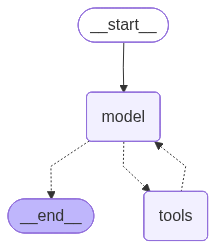

In [17]:
# 그래프 흐름: START → agent → tools → agent → ... → END
# agent 노드: LLM이 사용자 메시지를 받아 응답을 생성해요
# tools 노드: get_current_time, greet_user 도구를 실행해요
# 조건부 엣지: tool_call 유무에 따라 tools 또는 END로 분기해요
display(Image(demo_agent.get_graph().draw_mermaid_png()))

## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **V0 → V1 철학 전환**: "체인으로 묶는다" → "에이전트가 스스로 판단한다"로 패러다임이 바뀌었어요
- **패키지 재구조화**: `langchain_core`, `langchain_openai` 등으로 분산되었던 import가 `langchain.*`으로 통합되었어요
- **`init_chat_model`**: `"provider:model"` 형식으로 모든 공급자를 통일된 방식으로 초기화해요
- **Content Blocks**: 텍스트, 이미지, 도구 호출이 표준 블록 형식으로 통일되었어요; `content: str | list` 타입에 주의하세요
- **`create_agent`**: `create_react_agent`를 대체하는 V1 표준 에이전트 생성 함수예요
- **Breaking Changes**: `.text()` → `.text`, `str | list` content 타입, Python 3.10+ 요구사항에 주의하세요
- **Python 3.10+**: `match-case`, `str | list` 타입 힌트 등 현대적 Python 기능을 적극 활용해요

## 다음 노트북 예고

다음 `02-Product-Hierarchy.ipynb`에서는 **LangChain(Framework) vs LangGraph(Runtime) vs Deep Agents(Harness)** 의 제품 계층을 배워요. 각각이 언제, 왜 필요한지, 어떻게 조합해서 사용하는지 이해하면 전체 에코시스템이 한눈에 보일 거예요.